# **Regresión Lineal: Altura y Peso**

Datos reales de 200 registros de alturas y pesos humanos obtenidos en Hong Kong (1993).  
**Variable X:** Peso (Libras)  
**Variable Y:** Altura (Pulgadas)


## 1.- Carga del Dataset desde Excel

In [2]:
import pandas as pd
import numpy as np
df_raw = pd.read_excel("Estadistica_3202.xlsx", sheet_name="Hoja1", header=None)
df = df_raw.iloc[11:211, [2, 3]].copy()
df.columns = ["Altura_Pulgadas", "Peso_Libras"]
df["Altura_Pulgadas"] = pd.to_numeric(df["Altura_Pulgadas"], errors="coerce")
df["Peso_Libras"] = pd.to_numeric(df["Peso_Libras"], errors="coerce")
df = df.dropna().reset_index(drop=True)
print("Total de registros cargados:", len(df))
df.head(10)


Total de registros cargados: 200


,Altura_Pulgadas,Peso_Libras
0,65.78,112.99
1,71.52,136.49
2,69.40,153.03
3,68.22,142.34
4,67.79,144.30
5,68.70,123.30
6,69.80,141.49
7,70.01,136.46
8,67.90,112.37
9,66.78,120.67


## 2.- Visualización del Dataset

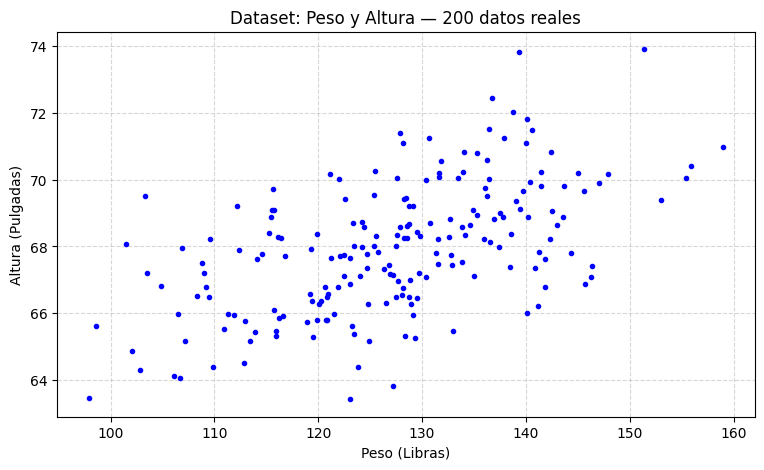

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(9, 5))
plt.plot(df["Peso_Libras"], df["Altura_Pulgadas"], "b.", markersize=6)
plt.xlabel("Peso (Libras)")
plt.ylabel("Altura (Pulgadas)")
plt.title("Dataset: Peso y Altura — 200 datos reales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3.- Estadísticas del Dataset

In [4]:
df.describe()

,Altura_Pulgadas,Peso_Libras
count,200.000000,200.000000
mean,67.949800,127.221950
std,1.940363,11.960959
min,63.430000,97.900000
25%,66.522500,119.895000
50%,67.935000,127.875000
75%,69.202500,136.097500
max,73.900000,158.960000


## 4.- Construcción del Modelo de Regresión Lineal

In [5]:
from sklearn.linear_model import LinearRegression
X = df["Peso_Libras"].values.reshape(-1, 1)
y = df["Altura_Pulgadas"].values
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("Modelo entrenado con", len(df), "datos")


Modelo entrenado con 200 datos


In [6]:
# Pendiente (coeficiente)
print("lin_reg.coef_      :", lin_reg.coef_)

lin_reg.coef_      : [0.09033719]


In [7]:
# Intercepto
print("lin_reg.intercept_ :", lin_reg.intercept_)

lin_reg.intercept_ : 56.45692590224269


In [8]:
print(f"\nEcuación de regresión:")
print(f"  Altura = {lin_reg.intercept_:.4f} + {lin_reg.coef_[0]:.4f} * Peso")


Ecuación de regresión:
  Altura = 56.4569 + 0.0903 * Peso


## 5.- Visualización de la Línea de Regresión

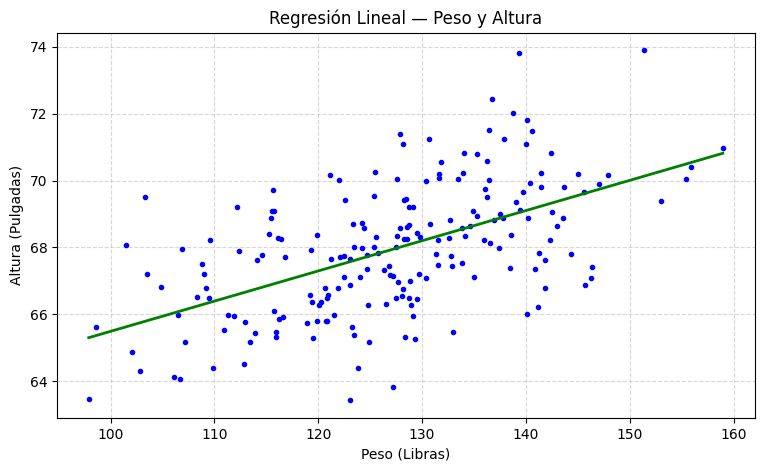

In [9]:
x_min_max = np.array([[df["Peso_Libras"].min()],
                       [df["Peso_Libras"].max()]])
y_pred_line = lin_reg.predict(x_min_max)
plt.figure(figsize=(9, 5))
plt.plot(df["Peso_Libras"], df["Altura_Pulgadas"], "b.", markersize=6, label="Datos reales (200)")
plt.plot(x_min_max, y_pred_line, "g-", linewidth=2, label="Línea de regresión")
plt.xlabel("Peso (Libras)")
plt.ylabel("Altura (Pulgadas)")
plt.title("Regresión Lineal — Peso y Altura")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 6.- Predicción de nuevos ejemplos

In [10]:
# Predecir la altura para un peso de 130 libras
x_new = np.array([[130]])
altura_pred = lin_reg.predict(x_new)
print(f"Para un peso de {x_new[0][0]} libras:")
print(f"  Altura estimada = {altura_pred[0]:.4f} pulgadas")

Para un peso de 130 libras:
  Altura estimada = 68.2008 pulgadas


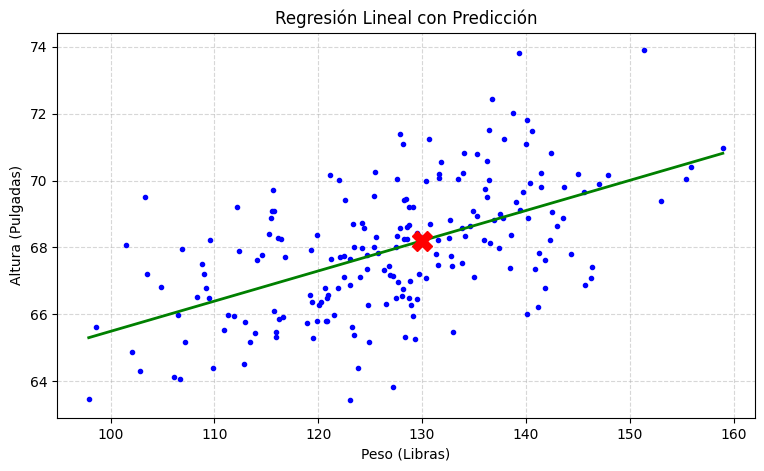

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(df["Peso_Libras"], df["Altura_Pulgadas"], "b.", markersize=6, label="Datos reales (200)")
plt.plot(x_min_max, y_pred_line, "g-", linewidth=2, label="Línea de regresión")
plt.plot(x_new, altura_pred, "rX", markersize=14, label=f"Predicción: {altura_pred[0]:.2f} pulg")
plt.xlabel("Peso (Libras)")
plt.ylabel("Altura (Pulgadas)")
plt.title("Regresión Lineal con Predicción")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()